In [2]:
from __future__ import absolute_import
from __future__ import print_function

import os # Configure which GPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import matplotlib.pyplot as plt
import numpy as np
import pickle
import time
import sys
import csv
import random
import torch
import torch.nn as nn

sys.path.append(os.getcwd())
from utils.NN_utils import BeamPredictionModel, BlockPredictionModel, BestGainPredictionModel
from utils.NN_utils import BeamPredictionLSTMModel, BlockPredictionLSTMModel, BestGainPredictionLSTMModel
from utils.NN_utils import preprocess_data
from utils.options import args_parser
from utils.mox_utils import setup_seed, get_save_dirs, np2torch, save_NN_results
from utils.data_utils import get_prepared_dataset, prepare_dataset
from utils.beam_utils import generate_dft_codebook, beamIdPair_to_beamPairId, beamPairId_to_beamIdPair
from utils.NN_utils import BeamPredictionModel, train_beampred_lstm_model
from utils.options import args_parser
from utils.alg_utils import HO_LowerBound_SINR
from utils.mox_utils import setup_seed, get_save_dirs, save_NN_results
from utils.plot_utils import plot_record_metrics
from utils.data_utils import get_prepared_dataset, prepare_dataset, augment_dataset
from utils.beam_utils import generate_dft_codebook
from utils.plot_utils import plt_color_list, plt_linestyle_list, plt_marker_list

%matplotlib inline

In [3]:
# 设置plt字体为Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 设置存储路径
paper_fig_save_dir = "./paper_figures"

# plot NN training curves

In [4]:
# plot NN training curves
beampred_NNtraining_path = "/home/ubuntu/niulab/Meet_Cobra/NN_result/200_800_3Dbeam_tx(1,32)_rx(1,8)_freq2.8e+10_Np8_mode0_lookahead10/logs/beampred_lstm_valAcc89.73%_2025-09-19_21:48:48.pkl"
gainpred_NNtraining_path = "/home/ubuntu/niulab/Meet_Cobra/NN_result/200_800_3Dbeam_tx(1,32)_rx(1,8)_freq2.8e+10_Np8_mode0_lookahead10/logs/gainpred_lstm_valMae4.07dB_2025-09-25_02:04:34.pkl"
inferpred_NNtraining_path = "/home/ubuntu/niulab/Meet_Cobra/NN_result/200_800_3Dbeam_tx(1,32)_rx(1,8)_freq2.8e+10_Np8_mode0_lookahead10/logs/inferpred_lstm_valMae3.20dB_2025-11-05_01:24:36.pkl"
with open(beampred_NNtraining_path, 'rb') as f:
    beampred_NNtraining_record = pickle.load(f)
with open(gainpred_NNtraining_path, 'rb') as f:
    gainpred_NNtraining_record = pickle.load(f)
with open(inferpred_NNtraining_path, 'rb') as f:    
    inferpred_NNtraining_record = pickle.load(f)

In [5]:
beampred_trainACC = np.array(beampred_NNtraining_record['record_metrics']['train_acc'])
beampred_valACC = np.array(beampred_NNtraining_record['record_metrics']['val_acc'])
beampred_trainTop3ACC = np.array(beampred_NNtraining_record['record_metrics']['train_top3_acc'])
beampred_valTop3ACC = np.array(beampred_NNtraining_record['record_metrics']['val_top3_acc'])
gainpred_trainMAE = np.array(gainpred_NNtraining_record['record_metrics']['train_mae'])
gainpred_valMAE = np.array(gainpred_NNtraining_record['record_metrics']['val_mae'])
inferpred_trainMAE = np.array(inferpred_NNtraining_record['record_metrics']['train_mae'])
inferpred_valMAE = np.array(inferpred_NNtraining_record['record_metrics']['val_mae'])

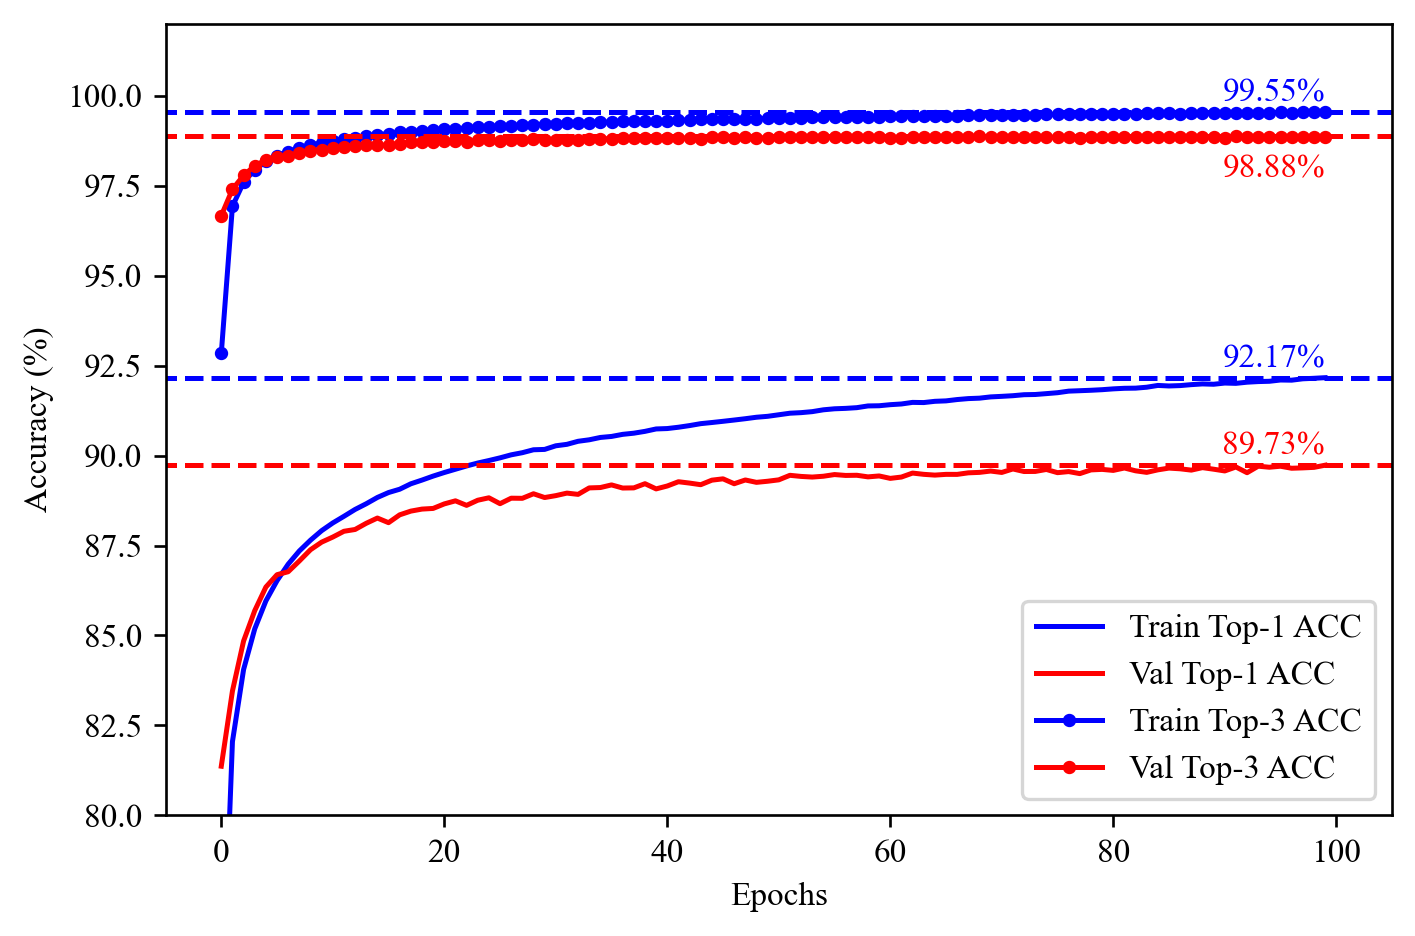

In [6]:
plt.figure(figsize=(6,4), dpi=240)
plt.plot(beampred_trainACC*100, label='Train Top-1 ACC', color='blue', marker='', linestyle='solid')
plt.plot(np.arange(-100, len(beampred_trainACC)+100),
         np.ones(len(beampred_trainACC)+200) * max(beampred_trainACC)*100,
         color='blue', linestyle='--', marker='')
plt.text(len(beampred_trainACC)-1, max(beampred_trainACC)*100+0.1,
         f'{max(beampred_trainACC)*100:.2f}%', va='bottom', ha='right', color='blue')

plt.plot(beampred_valACC*100, label='Val Top-1 ACC', color='red', marker='', linestyle='solid')
plt.plot(np.arange(-100, len(beampred_valACC)+100),
         np.ones(len(beampred_valACC)+200) * max(beampred_valACC)*100,
         color='red', linestyle='--', marker='')
plt.text(len(beampred_valACC)-1, max(beampred_valACC)*100+0.1,
         f'{max(beampred_valACC)*100:.2f}%', va='bottom', ha='right', color='red')

plt.plot(beampred_trainTop3ACC*100, label='Train Top-3 ACC', color='blue', marker='.', linestyle='solid')
plt.plot(np.arange(-100, len(beampred_trainTop3ACC)+100),
         np.ones(len(beampred_trainTop3ACC)+200) * max(beampred_trainTop3ACC)*100,
         color='blue', linestyle='--', marker='')
plt.text(len(beampred_trainTop3ACC)-1, max(beampred_trainTop3ACC)*100+0.1,
         f'{max(beampred_trainTop3ACC)*100:.2f}%', va='bottom', ha='right', color='blue')

plt.plot(beampred_valTop3ACC*100, label='Val Top-3 ACC', color='red', marker='.', linestyle='solid')
plt.plot(np.arange(-100, len(beampred_valTop3ACC)+100),
         np.ones(len(beampred_valTop3ACC)+200) * max(beampred_valTop3ACC)*100,
         color='red', linestyle='--', marker='')
plt.text(len(beampred_valTop3ACC)-1, max(beampred_valTop3ACC)*100-0.5,
         f'{max(beampred_valTop3ACC)*100:.2f}%', va='top', ha='right', color='red')

plt.legend()
# ax1.set_title('Beam Prediction Model Training Process')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xlim([-5, 105])
plt.ylim([80, 102])

plt.tight_layout()
plt.savefig(os.path.join(paper_fig_save_dir, 'NN_training_curves(a).pdf'))
plt.show()

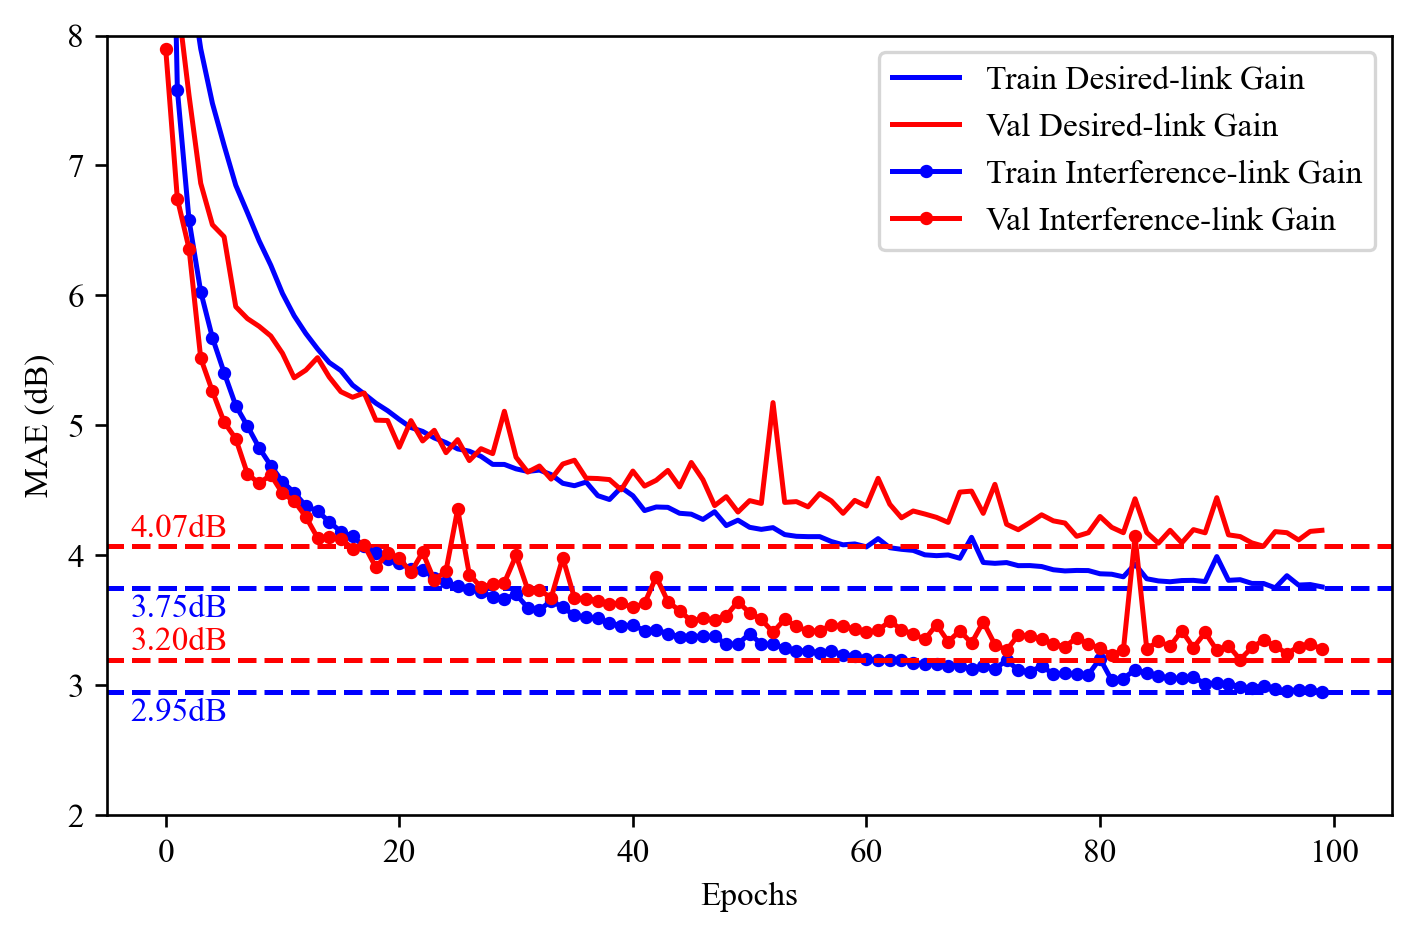

In [7]:
plt.figure(figsize=(6,4), dpi=240)
plt.plot(gainpred_trainMAE, label='Train Desired-link Gain', color='blue', marker='', linestyle='solid')
plt.plot(np.arange(-100, len(gainpred_trainMAE)+100),
         np.ones(len(gainpred_trainMAE)+200) * min(gainpred_trainMAE),
         color='blue', linestyle='--', marker='')
plt.text(-3, min(gainpred_trainMAE)-0.05,
         f'{min(gainpred_trainMAE):.2f}dB', va='top', ha='left', color='blue')

plt.plot(gainpred_valMAE, label='Val Desired-link Gain', color='red', marker='', linestyle='solid')
plt.plot(np.arange(-100, len(gainpred_valMAE)+100),
         np.ones(len(gainpred_valMAE)+200) * min(gainpred_valMAE),
         color='red', linestyle='--', marker='')
plt.text(-3, min(gainpred_valMAE)+0.02,
         f'{min(gainpred_valMAE):.2f}dB', va='bottom', ha='left', color='red')

plt.plot(inferpred_trainMAE, label='Train Interference-link Gain', color='blue', marker='.', linestyle='solid')
plt.plot(np.arange(-100, len(inferpred_trainMAE)+100),
         np.ones(len(inferpred_trainMAE)+200) * min(inferpred_trainMAE),
         color='blue', linestyle='--', marker='')
plt.text(-3, min(inferpred_trainMAE)-0.05,
         f'{min(inferpred_trainMAE):.2f}dB', va='top', ha='left', color='blue')

plt.plot(inferpred_valMAE, label='Val Interference-link Gain', color='red', marker='.', linestyle='solid')
plt.plot(np.arange(-100, len(inferpred_valMAE)+100),
         np.ones(len(inferpred_valMAE)+200) * min(inferpred_valMAE),
         color='red', linestyle='--', marker='')
plt.text(-3, min(inferpred_valMAE)+0.02,
         f'{min(inferpred_valMAE):.2f}dB', va='bottom', ha='left', color='red')

plt.legend()
# ax2.set_title('Gain Prediction Model Training Process')
plt.xlabel('Epochs')
plt.ylabel('MAE (dB)')
plt.xlim([-5, 105])
plt.ylim([2, 8])

plt.tight_layout()
plt.savefig(os.path.join(paper_fig_save_dir, 'NN_training_curves(b).pdf'))
plt.show()

# Paper exp1

In [8]:
# 为灵活修改plots中的strategy的名字,定义如下字典
change_strategyName_dict = dict()
change_strategyName_dict['Proposed'] = 'MEET-COBRA'
change_strategyName_dict['Oracle-LP-LB'] = 'Oracle-CR-LB'

result_path = "/home/ubuntu/niulab/Meet_Cobra/experiment/results_paper_exp1/lbd1.00_800_830.0_2025-12-22 06:26:16/sim_result_dict.npy"
with open(result_path, 'rb') as f:
    sim_result_dict = np.load(f, allow_pickle=True).item()
args = sim_result_dict.pop('args')
data_rate_list = sim_result_dict.pop('data_rate_list')

# 修改strategy的名字
new_sim_result_dict = dict()
for k,v in sim_result_dict.items():
    if k in change_strategyName_dict.keys():
        new_sim_result_dict[change_strategyName_dict[k]] = v
    else:
        new_sim_result_dict[k] = v
        
sim_result_dict = new_sim_result_dict
strategy_name_list = list(sim_result_dict.keys())
print('strategy_name_list: ',strategy_name_list)

strategy_name_list:  ['MEET-COBRA', 'Oracle-MC', 'Oracle-CR-LB', 'Reactive-OBRA', 'w/o GAP-HO', 'w/o PET-BF', 'w/o OTR-RA']


In [9]:
sim_result_dict['Oracle-CR-LB']['avg_system_power_list'][-2] =185.43
sim_result_dict['Oracle-CR-LB']['avg_system_power_list'][-1] =185.43

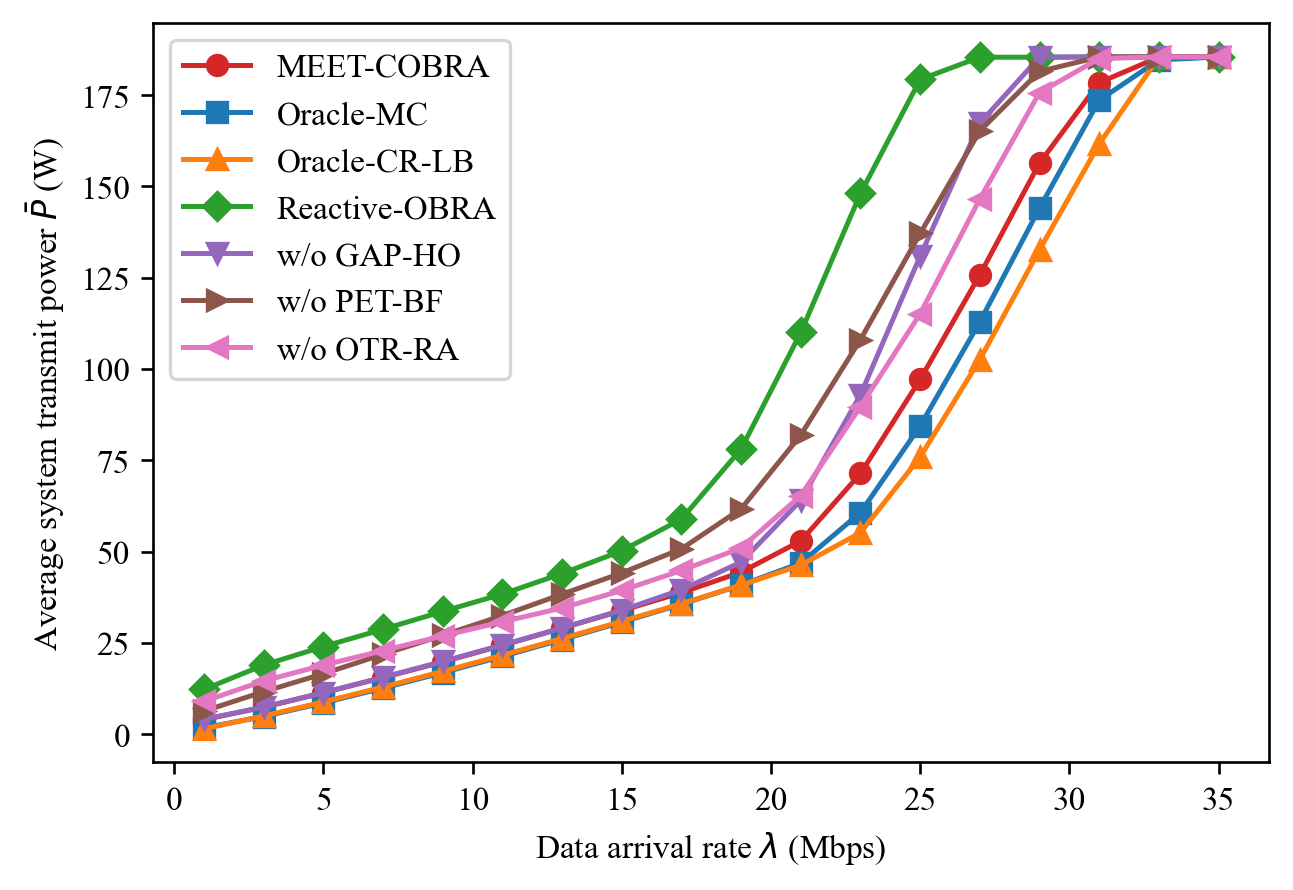

In [10]:
plt.figure(figsize=(6,4), dpi=240)
for i, strategy_name in enumerate(sim_result_dict.keys()):
    plot_len = min(len(data_rate_list),len(sim_result_dict[strategy_name]["avg_system_power_list"]))
    plt.plot(
        data_rate_list[: plot_len]/1e6,
        sim_result_dict[strategy_name]["avg_system_power_list"][
            : plot_len
        ],
        linestyle=plt_linestyle_list[0],
        color=plt_color_list[i],
        marker=plt_marker_list[i],
        label=strategy_name,
    )
plt.legend()
plt.xlabel(r"Data arrival rate $\lambda$ (Mbps)")
# plt.xscale("log")
plt.ylabel(r"Average system transmit power $\bar{P}$ (W)")
plt.savefig(os.path.join(paper_fig_save_dir, 'power_comparison_curves.pdf'))
plt.show()

In [11]:
# 直接print各条曲线的结果，以字典形式存储
csv_list = list()

csv_row = data_rate_list[: plot_len]
csv_row = [f"power for lambda={lbd/1e6:.0f}" for lbd in csv_row]
csv_row.insert(0, "scheme name")
csv_list.append(csv_row)

for i, strategy_name in enumerate(sim_result_dict.keys()):
    plot_len = min(len(data_rate_list),len(sim_result_dict[strategy_name]["avg_system_power_list"]))
    csv_row = sim_result_dict[strategy_name]["avg_system_power_list"][: plot_len]
    csv_row = list(csv_row)
    csv_row.insert(0, strategy_name)
    csv_list.append(csv_row)
# 以csv表格的形式存储结果
print(csv_list)
 
# 打开文件并写入数据
with open('power vs lambda.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(csv_list)

[['scheme name', 'power for lambda=1', 'power for lambda=3', 'power for lambda=5', 'power for lambda=7', 'power for lambda=9', 'power for lambda=11', 'power for lambda=13', 'power for lambda=15', 'power for lambda=17', 'power for lambda=19', 'power for lambda=21', 'power for lambda=23', 'power for lambda=25', 'power for lambda=27', 'power for lambda=29', 'power for lambda=31', 'power for lambda=33', 'power for lambda=35'], ['MEET-COBRA', 4.009505016722407, 7.414709030100344, 11.346688963210712, 15.53646822742475, 19.802889632107014, 24.340535117056827, 29.04918394648828, 33.86004013377926, 38.77942474916388, 44.37808026755853, 52.931264214046884, 71.40797993311055, 97.15165217391312, 125.81531772575242, 156.39862207357842, 178.4400133779261, 185.42685618729053, 185.52337792642092], ['Oracle-MC', 1.7547892976588666, 4.84701003344482, 8.596073578595323, 12.62248829431438, 16.86532441471571, 21.320769230769212, 25.934494983277574, 30.69138461538463, 35.60488294314382, 40.86006688963208, 4

In [12]:
# 直接print各条曲线的结果，以字典形式存储
csv_list = list()

csv_row = data_rate_list[: plot_len]
csv_row = [f"violation probability for lambda={lbd/1e6:.0f}" for lbd in csv_row]
csv_row.insert(0, "scheme name")
csv_list.append(csv_row)

for i, strategy_name in enumerate(sim_result_dict.keys()):
    plot_len = min(len(data_rate_list),len(sim_result_dict[strategy_name]["vio_prob_list"]))
    csv_row = sim_result_dict[strategy_name]["vio_prob_list"][: plot_len]
    csv_row = list(csv_row)
    csv_row.insert(0, strategy_name)
    csv_list.append(csv_row)
# 以csv表格的形式存储结果
print(csv_list)
 
# 打开文件并写入数据
with open('violation probability vs lambda.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(csv_list)

[['scheme name', 'violation probability for lambda=1', 'violation probability for lambda=3', 'violation probability for lambda=5', 'violation probability for lambda=7', 'violation probability for lambda=9', 'violation probability for lambda=11', 'violation probability for lambda=13', 'violation probability for lambda=15', 'violation probability for lambda=17', 'violation probability for lambda=19', 'violation probability for lambda=21', 'violation probability for lambda=23', 'violation probability for lambda=25', 'violation probability for lambda=27', 'violation probability for lambda=29', 'violation probability for lambda=31', 'violation probability for lambda=33', 'violation probability for lambda=35'], ['MEET-COBRA', 0.10964683246535772, 0.11040514543325683, 0.11543347136865449, 0.12236525219168098, 0.12870191932014402, 0.13890804021944325, 0.14700787014374847, 0.16892374044330677, 0.22426559789182526, 0.34034668598819806, 0.7572035671758799, 0.8778059935176499, 0.7215898545371655, 

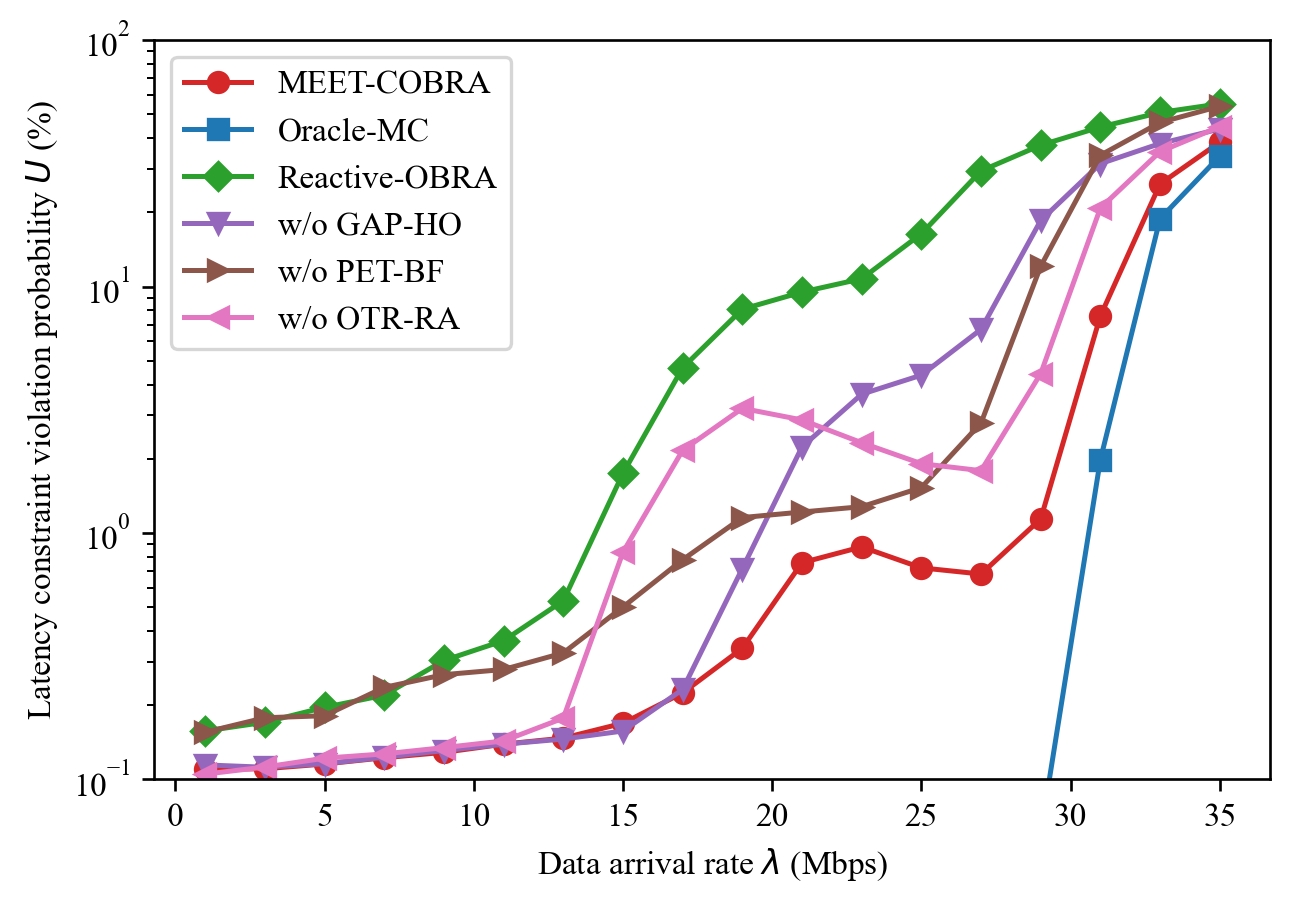

In [18]:
plt.figure(figsize=(6,4), dpi=240)
for i, strategy_name in enumerate(sim_result_dict.keys()):
    if strategy_name == "Oracle-CR-LB":
        continue
    plot_len = min(len(data_rate_list),len(sim_result_dict[strategy_name]["avg_system_power_list"]))
    plt.plot(
        data_rate_list[: plot_len]/1e6,
        sim_result_dict[strategy_name]["vio_prob_list"][: plot_len],
        linestyle=plt_linestyle_list[0],
        color=plt_color_list[i],
        marker=plt_marker_list[i],
        label=strategy_name,
    )
plt.legend()
plt.xlabel(r"Data arrival rate $\lambda$ (Mbps)")
# plt.ylim(0, 100)
plt.yscale("log")
plt.ylim(1e-1, 1e2)
plt.ylabel(r"Latency constraint violation probability $U$ (%)")
plt.savefig(os.path.join(paper_fig_save_dir, 'violation_prob_comparison_curves.pdf'))
plt.show()

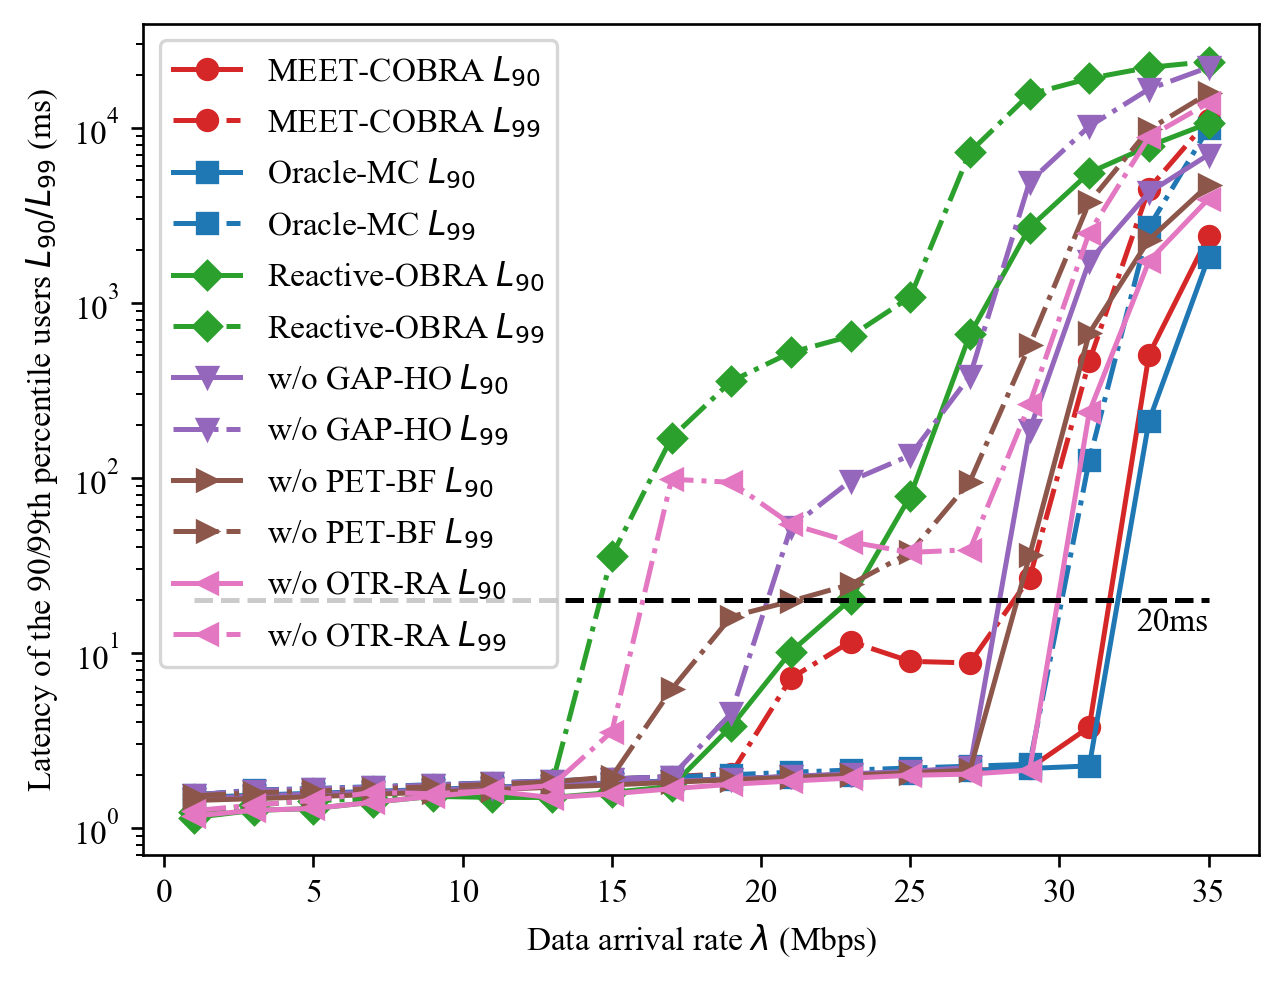

In [17]:

plt.figure(figsize=(6,4.5), dpi=240)
for i, strategy_name in enumerate(sim_result_dict.keys()):
    if strategy_name == "Oracle-CR-LB":
        continue
    avg_latency_90th_list = []
    avg_latency_95th_list = []
    avg_latency_99th_list = []
    for queuelen_4eachVeh_record in sim_result_dict[strategy_name]["queuelen_4eachVeh_record_list"]:
        all_veh_queuelens = []
        for frame_record in queuelen_4eachVeh_record.values():
            all_veh_queuelens.extend(frame_record.values())
        all_veh_queuelens = np.array(all_veh_queuelens)
        queuelen_90th = np.percentile(all_veh_queuelens, 90)
        queuelen_95th = np.percentile(all_veh_queuelens, 95)
        queuelen_99th = np.percentile(all_veh_queuelens, 99)
        latency_90th = (queuelen_90th / args.data_rate + args.slot_len) * 1000
        latency_95th = (queuelen_95th / args.data_rate + args.slot_len) * 1000
        latency_99th = (queuelen_99th / args.data_rate + args.slot_len) * 1000
        avg_latency_90th_list.append(latency_90th)
        avg_latency_95th_list.append(latency_95th)
        avg_latency_99th_list.append(latency_99th)
    plot_len = min(len(data_rate_list),len(sim_result_dict[strategy_name]["avg_system_power_list"]))
    plt.plot(
        data_rate_list[:plot_len]/1e6,
        avg_latency_90th_list[:plot_len],
        linestyle=plt_linestyle_list[0],
        color=plt_color_list[i],
        marker=plt_marker_list[i],
        label=strategy_name+r' $L_{90}$',
    )
    # plt.plot(
    #     data_rate_list[:plot_len]/1e6,
    #     avg_latency_95th_list[:plot_len],
    #     linestyle=plt_linestyle_list[1],
    #     color=plt_color_list[i],
    #     marker=plt_marker_list[i],
    #     label=strategy_name+r' $L_{95}$',
    # )
    plt.plot(
        data_rate_list[:plot_len]/1e6,
        avg_latency_99th_list[:plot_len],
        linestyle=plt_linestyle_list[2],
        color=plt_color_list[i],
        marker=plt_marker_list[i],
        label=strategy_name+r' $L_{99}$',
    )
# 在时延阈值上画一条横线
plt.plot(data_rate_list/1e6, [args.lat_slot_ub * args.slot_len * 1000] * len(data_rate_list), linestyle="--", color="black")
plt.text(data_rate_list[-1]/1e6, args.lat_slot_ub * args.slot_len * 1000 - 2,
         f'{args.lat_slot_ub * args.slot_len * 1000:.0f}ms', va='top', ha='right', color='black')
plt.legend()
plt.xlabel(r"Data arrival rate $\lambda$ (Mbps)")
# plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"Latency of the 90/99th percentile users $L_{90}/L_{99}$ (ms)")
plt.savefig(os.path.join(paper_fig_save_dir, 'latency_90th_99th_comparison_curves.pdf'))
plt.show()

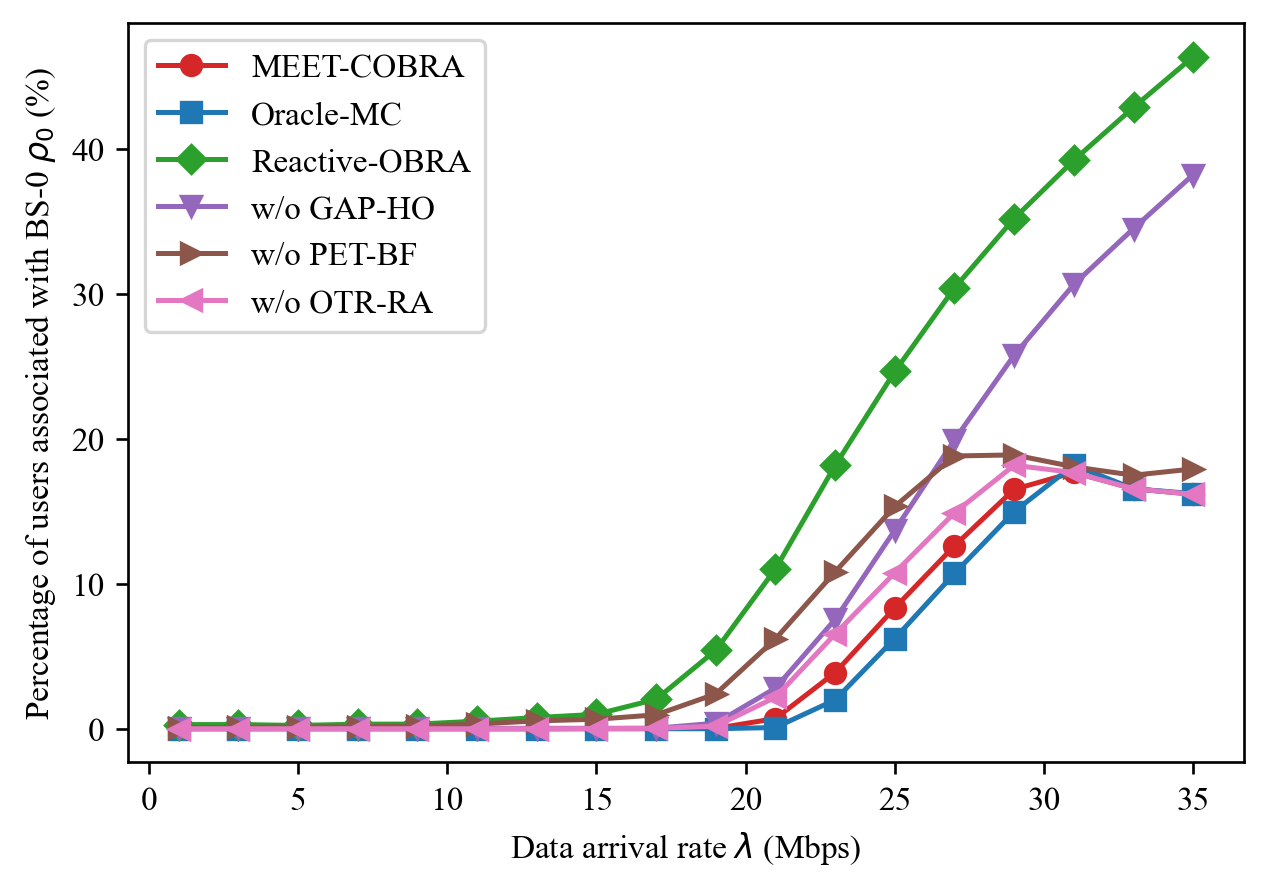

In [15]:
plt.figure(figsize=(6,4), dpi=240)
plt.xlabel(r"Data arrival rate $\lambda$ (Mbps)")
plt.ylabel(r"Percentage of users associated with BS-0 $\rho_0$ (%)")
for i, strategy_name in enumerate(sim_result_dict.keys()):
    if strategy_name == "Oracle-CR-LB":
        continue
    avg_carnum_under_BS0 = np.array(sim_result_dict[strategy_name]["carnum_under_BS_list"]).mean(axis=-2)
    plot_len = min(len(data_rate_list),len(sim_result_dict[strategy_name]["avg_system_power_list"]))
    plt.plot(
        data_rate_list[:plot_len]/1e6,
        100 * avg_carnum_under_BS0[:plot_len, 0]/avg_carnum_under_BS0[:plot_len,:].sum(axis=-1),
        linestyle=plt_linestyle_list[0],
        color=plt_color_list[i],
        marker=plt_marker_list[i],
        label=f"{strategy_name}",
    )
plt.legend()
plt.savefig(os.path.join(paper_fig_save_dir, 'BS0_assoc_ratio_comparison_curves.pdf'))
plt.show()